In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Interest Rate 

In [5]:
df.columns = df.columns.str.strip()

# EDA

Text(0.5, 1.0, 'Is the company Bankrupt or not')

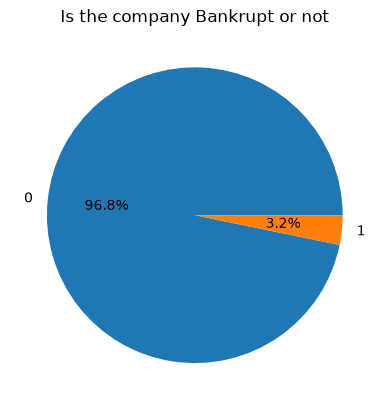

In [6]:
import matplotlib.pyplot as plt
class_count = df["Bankrupt?"].value_counts()
plt.pie(class_count ,labels=class_count.index , autopct="%1.1f%%")
plt.title("Is the company Bankrupt or not")

<Axes: xlabel='Debt ratio %', ylabel='Count'>

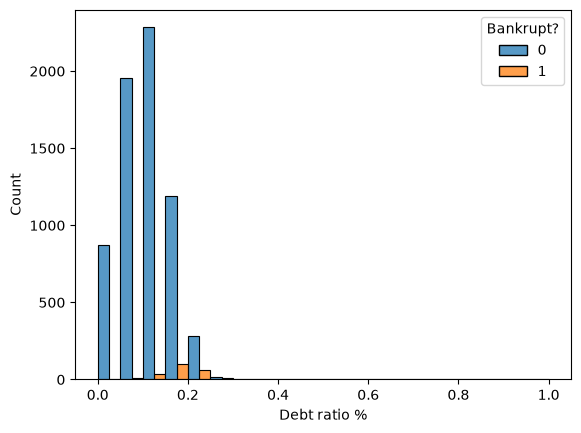

In [7]:
sns.histplot(
    data=df,
    x="Debt ratio %",
    hue="Bankrupt?",
    multiple="dodge",
    bins=20
)

# Correlation Heatmaps

In [8]:
corr_matrix = df.corr()

In [9]:
df.corr()["Bankrupt?"].sort_values(ascending=False)

Bankrupt?                                                  1.000000
Debt ratio %                                               0.250161
Current Liability to Assets                                0.194494
Borrowing dependency                                       0.176543
Current Liability to Current Assets                        0.171306
                                                             ...   
ROA(C) before interest and depreciation before interest   -0.260807
ROA(B) before interest and depreciation after tax         -0.273051
ROA(A) before interest and % after tax                    -0.282941
Net Income to Total Assets                                -0.315457
Net Income Flag                                                 NaN
Name: Bankrupt?, Length: 96, dtype: float64

<Axes: >

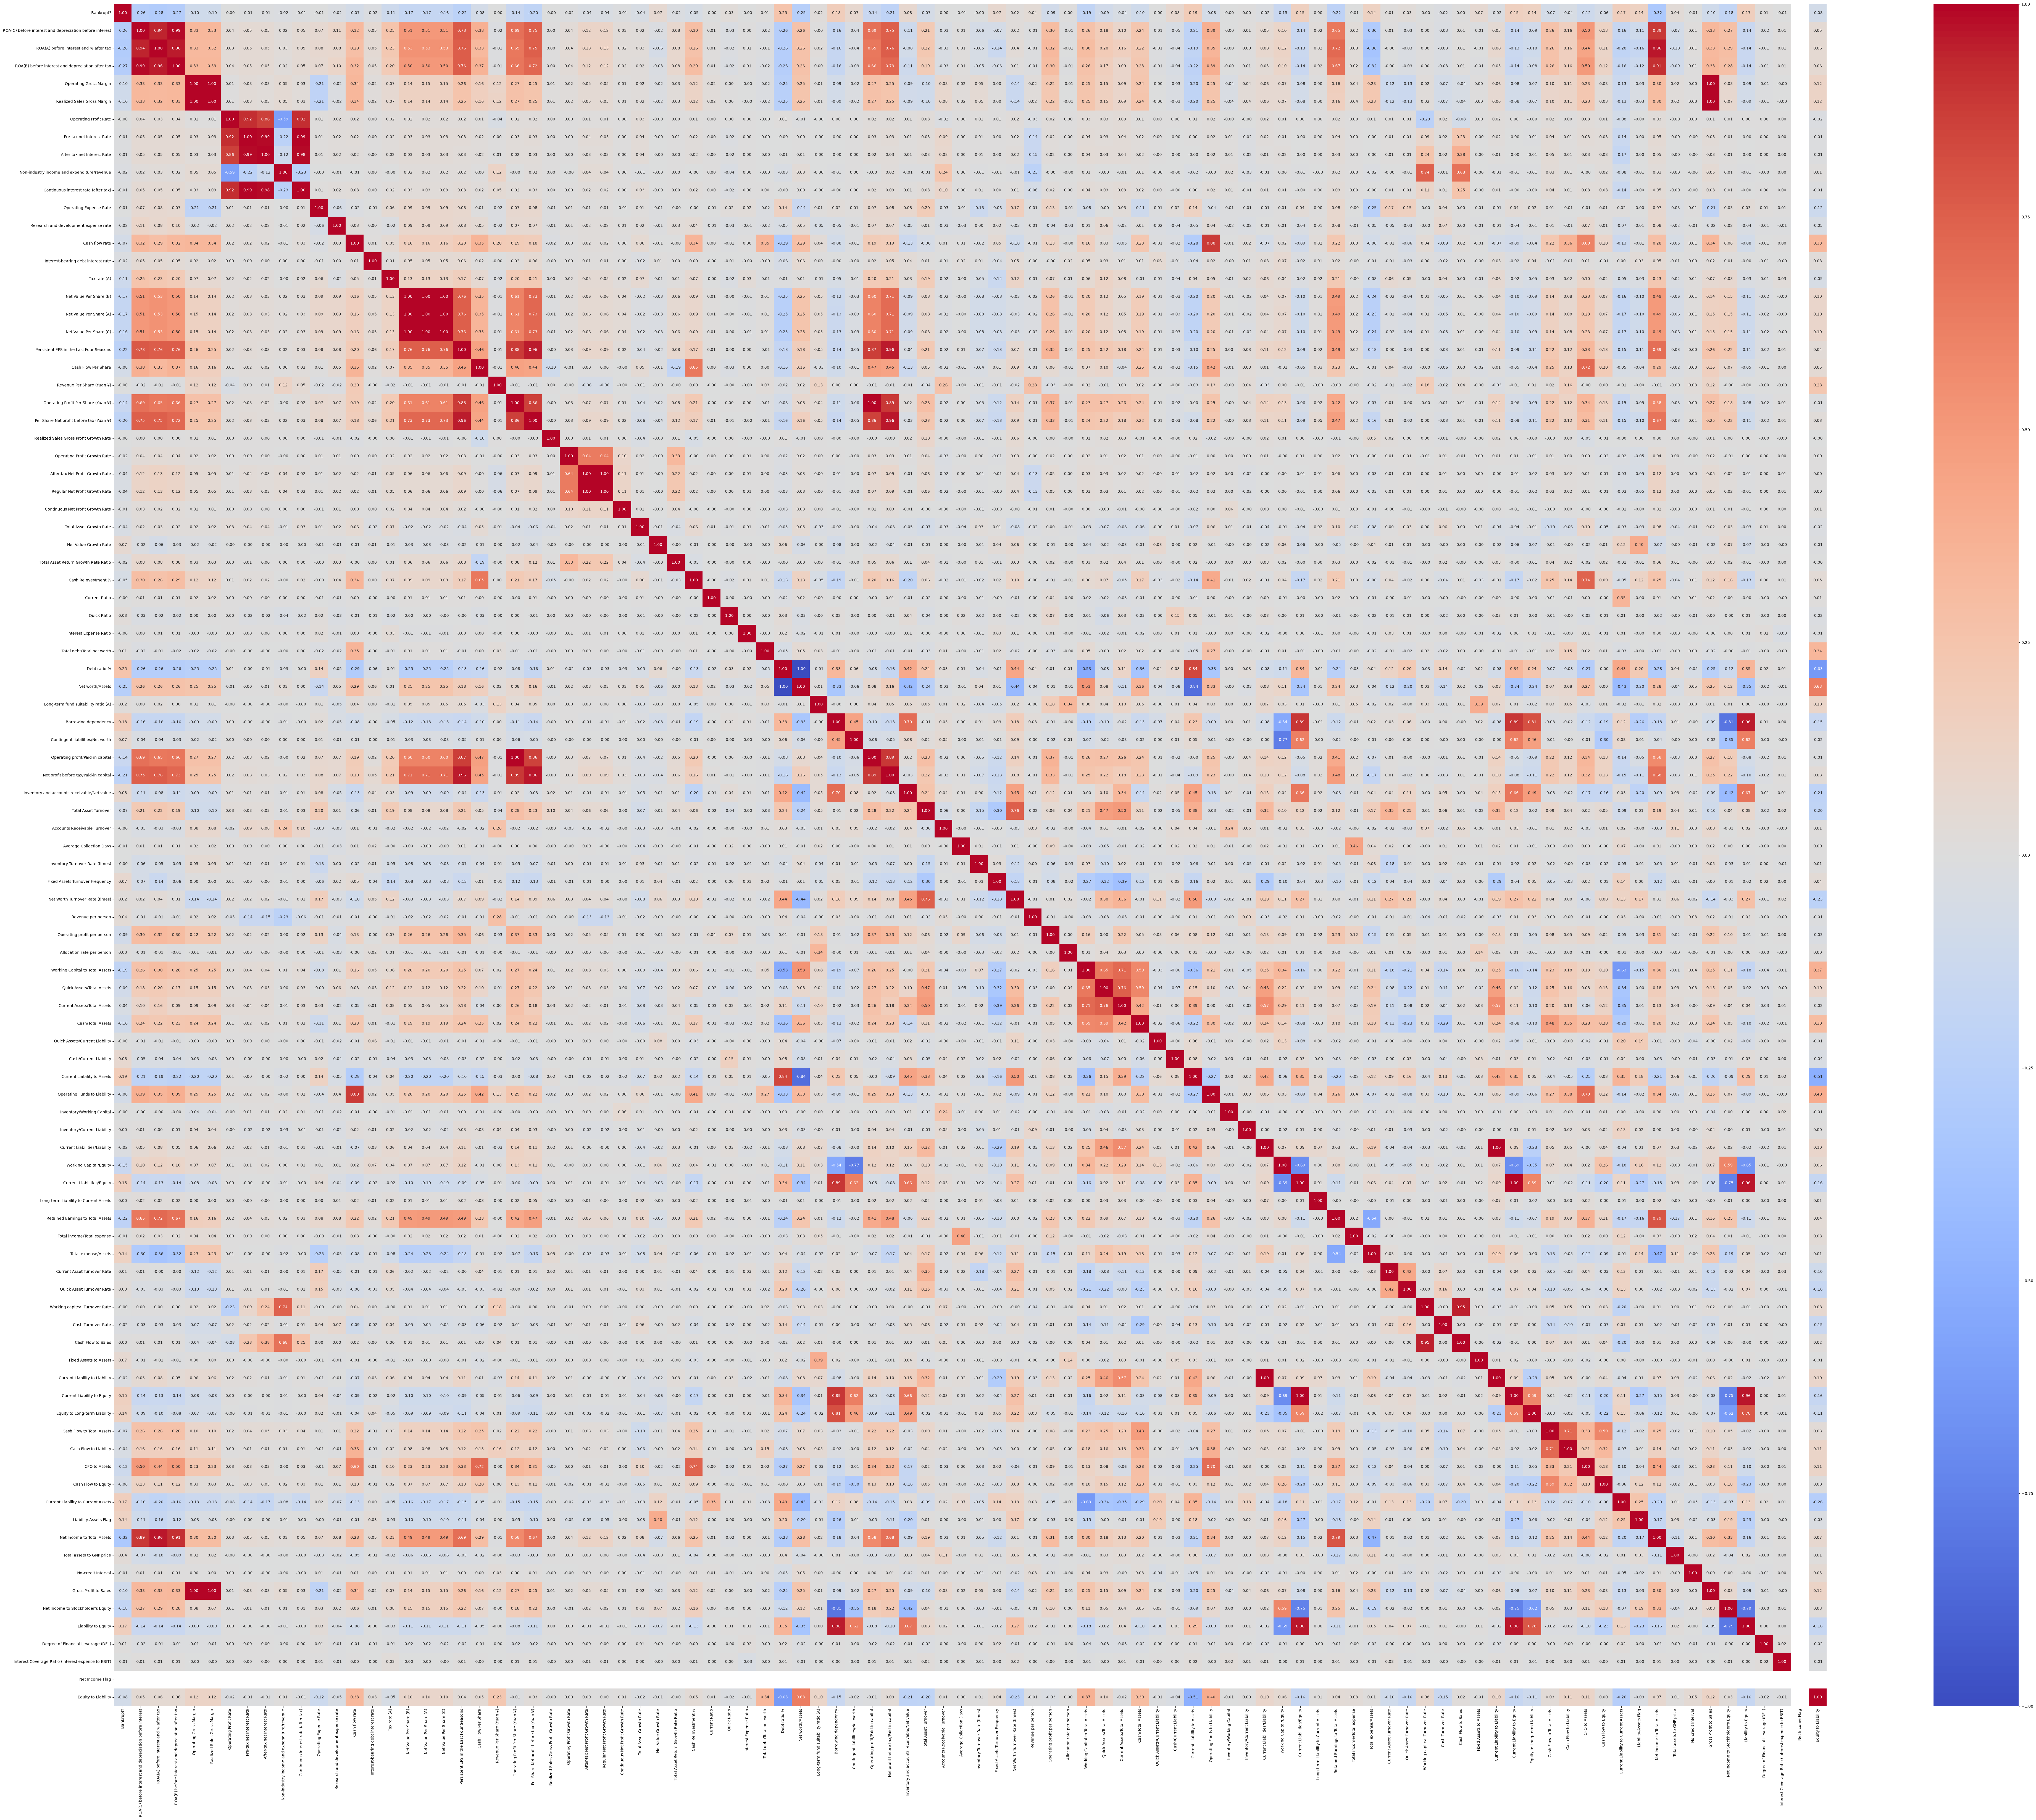

In [10]:
plt.figure(figsize=[100,80])
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Feature Engineering

In [11]:
new_columns = []

for c in df.columns:
    new_columns.append(c.strip())

df.columns = new_columns

constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

df.drop(columns=constant_cols, inplace=True)

In [12]:
X = df.drop(["Bankrupt?"],axis=1)
y = df["Bankrupt?"]

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test =  train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
# SVM Model
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
svc = SVC(class_weight={0: 1, 1: 15}, ensemble=False,kernel="linear",C=1)
svc.fit(X_train_scaled,y_train)

y_pred = svc.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, f1_score

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Classification Report : \n", classification_report(y_test,y_pred))
print("f1 score :", f1_score(y_test,y_pred))
print("Accuracy :",confusion_matrix(y_test,y_pred))

TypeError: SVC.__init__() got an unexpected keyword argument 'ensemble'

In [ ]:
C_vals = [0.5,1,2,3,4,5]

for c_vals in C_vals:
    svc = SVC(class_weight='balanced',kernel="linear",C=c_vals)
    svc.fit(X_train_scaled,y_train)

    y_pred = svc.predict(X_test_scaled)
    print("c", c_vals, "f1 score :", f1_score(y_test,y_pred))

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled,y_train)

y_prob = model.predict_proba(X_test_scaled)[:,1]

threshold = 0.8
y_pred_new = (y_prob > threshold).astype(int)

#Evaluate
print("Logistic Regression Model")
print("Precision :",precision_score(y_test,y_pred_new))
print("Recall score :",recall_score(y_test,y_pred_new))
print("f1 score :",f1_score(y_test,y_pred_new))
print("Accuracy :",accuracy_score(y_test,y_pred_new))
print("CM :",confusion_matrix(y_test,y_pred_new))

In [ ]:
model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7,0.8, 0.85, 0.9, 0.95]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test, y_pred_t):.3f}, "
          f"Recall={recall_score(y_test, y_pred_t):.3f}, "
          f"F1={f1_score(y_test, y_pred_t):.3f}")

# Train & Test

In [ ]:
X1 = df.drop(["Bankrupt?"],axis=1)
y1= df["Bankrupt?"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X1_train,X1_test,y1_train,y1_test =  train_test_split(
    X1, y1, test_size=0.2, random_state=42)

#Scaling
scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.fit_transform(X1_test)

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
model = LogisticRegression()
model.fit(X1_train_scaled,y1_train)

y1_pred = model.predict(X1_test_scaled)

#Evaluate
print("Logistic Regression Model")
print("Precision :",precision_score(y1_test,y1_pred))
print("Recall score :",recall_score(y1_test,y1_pred))
print("f1 score :",f1_score(y1_test,y1_pred))
print("Accuracy :",accuracy_score(y1_test,y1_pred))
print("CM :",confusion_matrix(y1_test,y1_pred))

In [ ]:
# #KNN
# from sklearn.neighbors import KNeighborsClassifier

# knn_model = KNeighborsClassifier(n_neighbors=11)
# knn_model.fit(X_train_scaled,y_train)

# y_pred = knn_model.predict(X_test_scaled)

# #Evaluate
# print("KNN Model")
# print("Precision :",precision_score(y_test,y_pred))
# print("Recall score :",recall_score(y_test,y_pred))
# print("f1 score :",f1_score(y_test,y_pred))
# print("Accuracy :",accuracy_score(y_test,y_pred))
# print("CM :",confusion_matrix(y_test,y_pred))